# Conversion Rate Challenge — Exploratory Data Analysis (EDA)


## 1. Project Overview

The goal of this project is to predict whether a visitor will subscribe to the newsletter of **Data Science Weekly**.

This notebook focuses on:

- Understanding the dataset
- Exploring the variables
- Detecting patterns linked to conversion
- Identifying potential preprocessing steps
- Preparing the data for machine learning models


## 2. Import Libraries

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 3. Load Dataset

In [34]:
train = pd.read_csv('../data/raw/conversion_data_train.csv')

train.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [35]:
print(f"Dataset shape: {train.shape}")

Dataset shape: (284580, 6)


In [36]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   country              284580 non-null  str  
 1   age                  284580 non-null  int64
 2   new_user             284580 non-null  int64
 3   source               284580 non-null  str  
 4   total_pages_visited  284580 non-null  int64
 5   converted            284580 non-null  int64
dtypes: int64(4), str(2)
memory usage: 13.0 MB



## 4. Dataset Description

| Feature | Description |
|---|---|
| country | Visitor country |
| age | Visitor age |
| new_user | Whether the visitor is a new user |
| source | Traffic acquisition source |
| total_pages_visited | Number of pages visited |
| converted | Target variable (1 = subscribed, 0 = not subscribed) |


## 5. Missing Values

In [37]:
train.isnull().sum()

country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

In [38]:
(train.isnull().mean() * 100).sort_values(ascending=False)

country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64

## 6. Duplicate Rows

In [39]:
duplicates = train.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 268769


Duplicate rows were detected, but they were kept in the dataset because they may correspond to legitimate repeated user behaviors.

## 7. Target Variable Distribution

In [40]:
train['converted'].value_counts()

converted
0    275400
1      9180
Name: count, dtype: int64

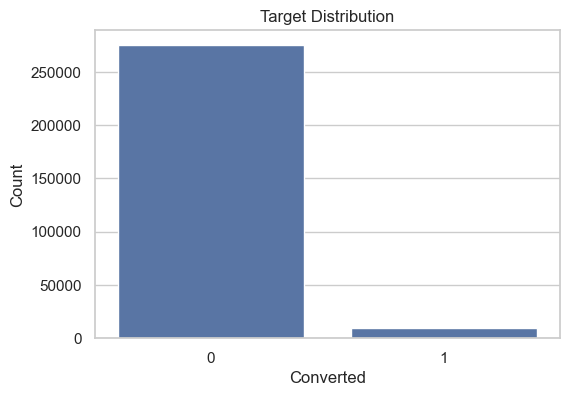

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=train, x='converted')
plt.title('Target Distribution')
plt.xlabel('Converted')
plt.ylabel('Count')
plt.show()

In [42]:
conversion_rate = train['converted'].mean() * 100
print(f"Conversion rate: {conversion_rate:.2f}%")

Conversion rate: 3.23%



### Observation

- The dataset is highly imbalanced.
- Most visitors do not subscribe.
- F1-score will be more relevant than accuracy.


## 8. Numerical Features Analysis

In [43]:
train.describe()

,age,new_user,total_pages_visited,converted
count,284580.000000,284580.000000,284580.000000,284580.000000
mean,30.564203,0.685452,4.873252,0.032258
std,8.266789,0.464336,3.341995,0.176685
min,17.000000,0.000000,1.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000
max,123.000000,1.000000,29.000000,1.000000


### Age Distribution

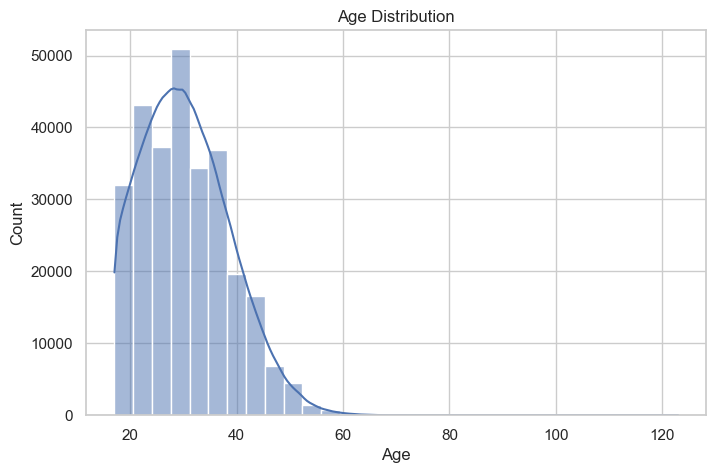

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(train['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

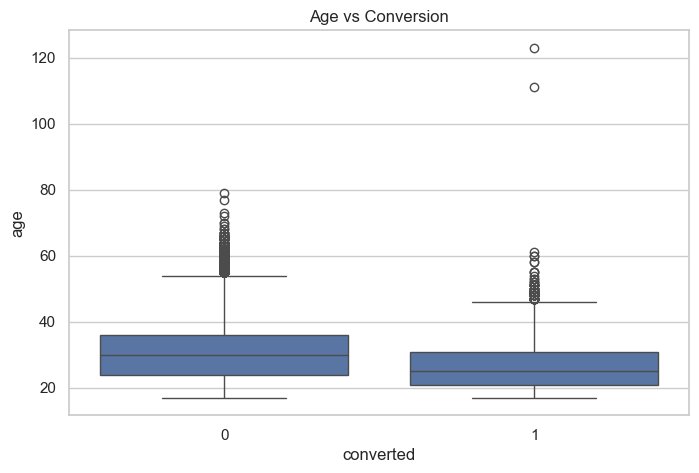

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='converted', y='age')
plt.title('Age vs Conversion')
plt.show()

### Total Pages Visited

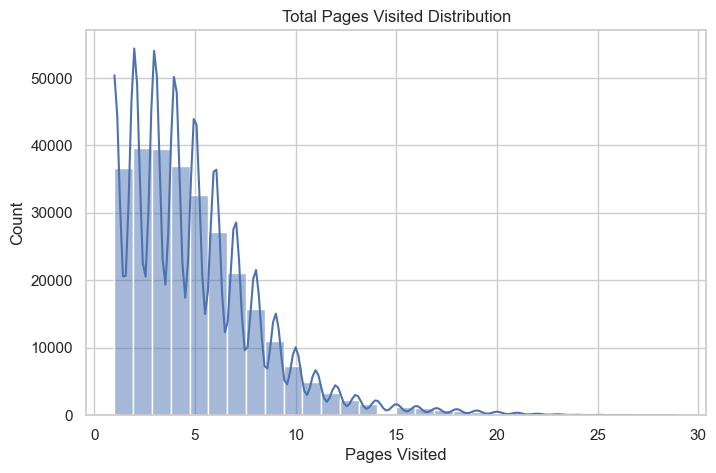

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(train['total_pages_visited'], bins=30, kde=True)
plt.title('Total Pages Visited Distribution')
plt.xlabel('Pages Visited')
plt.show()

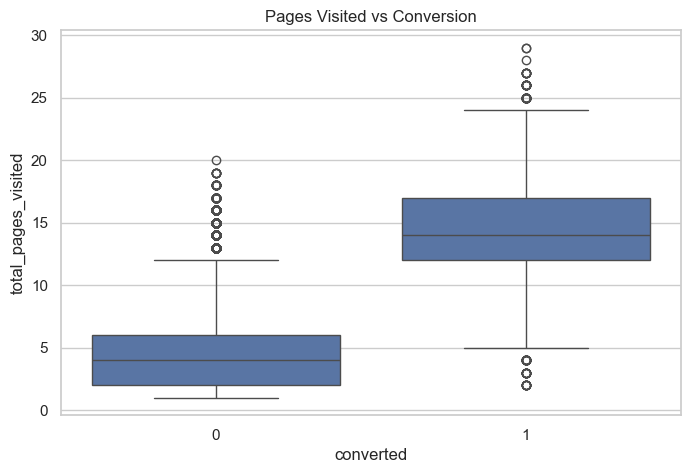

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='converted', y='total_pages_visited')
plt.title('Pages Visited vs Conversion')
plt.show()

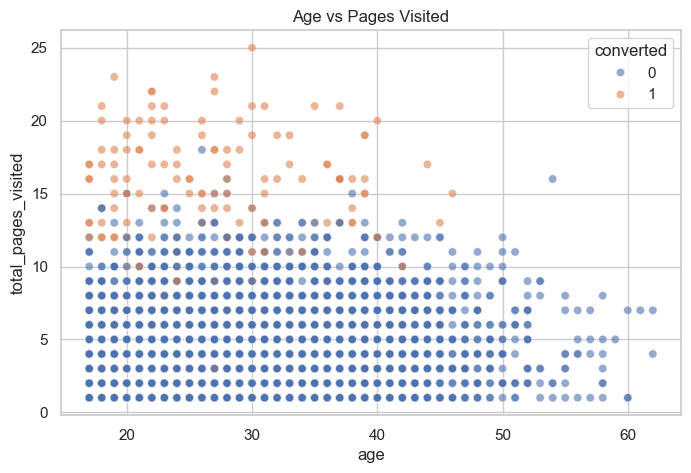

In [48]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=train.sample(min(5000, len(train))),
    x='age',
    y='total_pages_visited',
    hue='converted',
    alpha=0.6
)
plt.title('Age vs Pages Visited')
plt.show()

## 9. Categorical Features Analysis

### Country Analysis

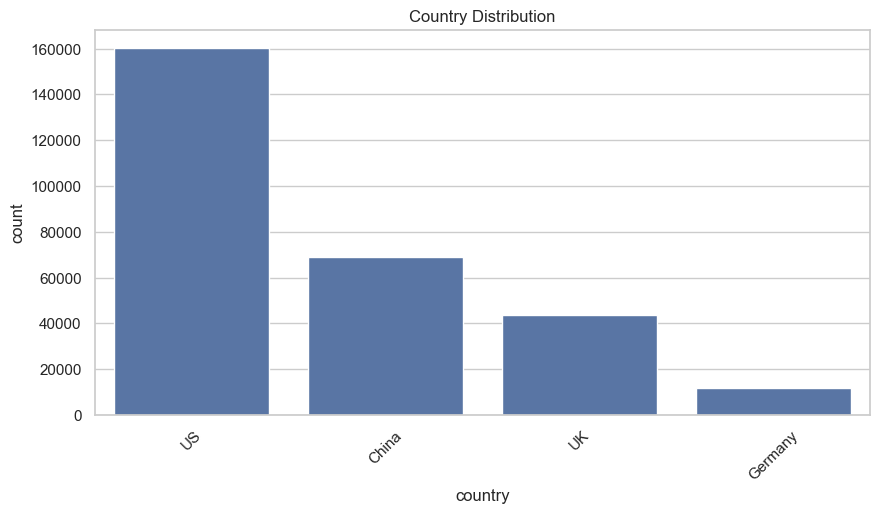

In [49]:
plt.figure(figsize=(10,5))
sns.countplot(data=train, x='country', order=train['country'].value_counts().index)
plt.title('Country Distribution')
plt.xticks(rotation=45)
plt.show()

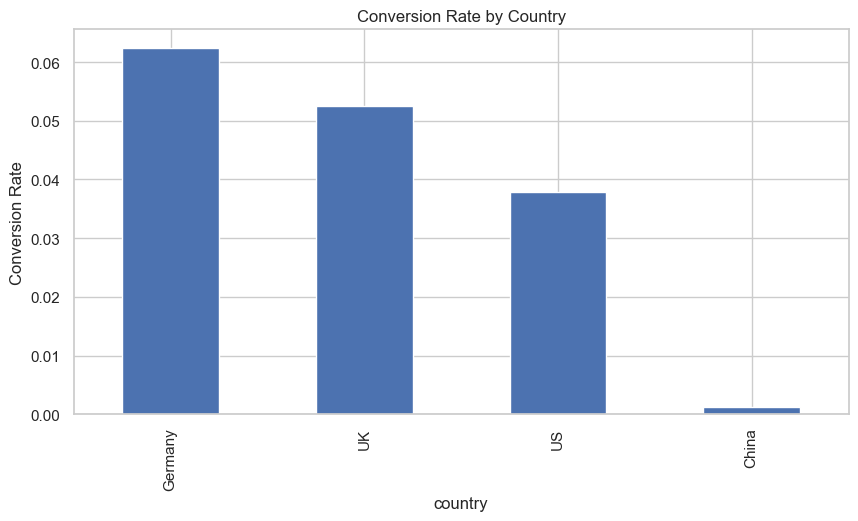

In [50]:
country_conversion = train.groupby('country')['converted'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_conversion.plot(kind='bar')
plt.title('Conversion Rate by Country')
plt.ylabel('Conversion Rate')
plt.show()

### Source Analysis

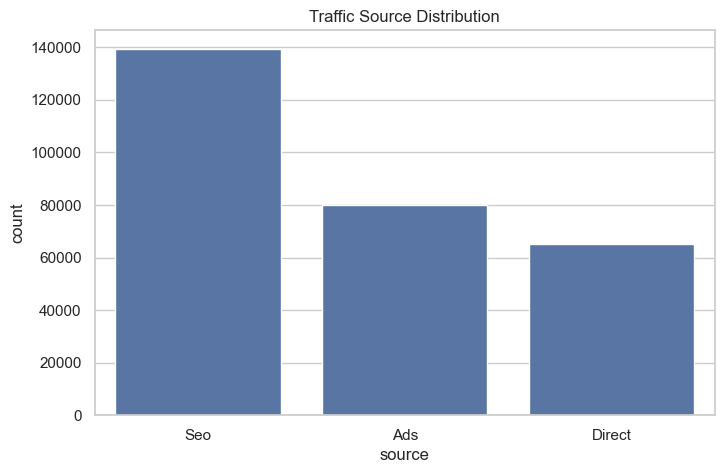

In [51]:
plt.figure(figsize=(8,5))
sns.countplot(data=train, x='source', order=train['source'].value_counts().index)
plt.title('Traffic Source Distribution')
plt.show()

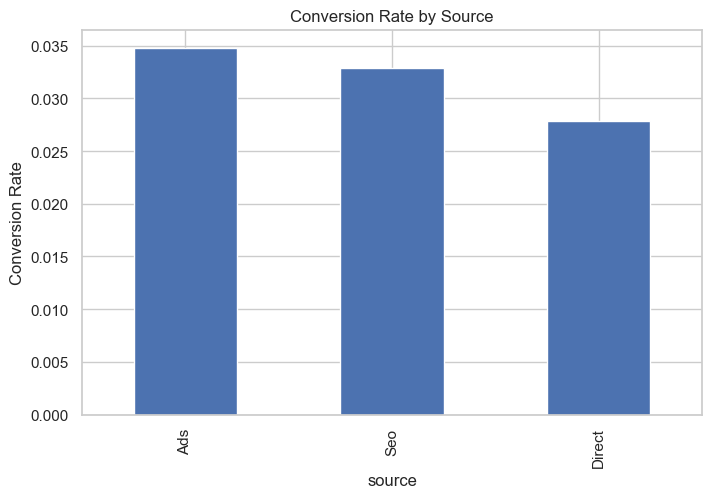

In [52]:
source_conversion = train.groupby('source')['converted'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
source_conversion.plot(kind='bar')
plt.title('Conversion Rate by Source')
plt.ylabel('Conversion Rate')
plt.show()

### New User Analysis

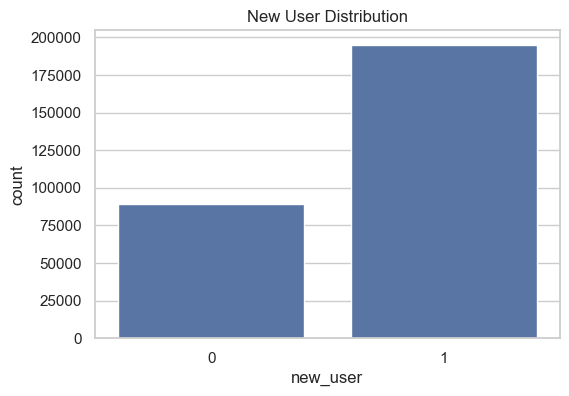

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(data=train, x='new_user')
plt.title('New User Distribution')
plt.show()

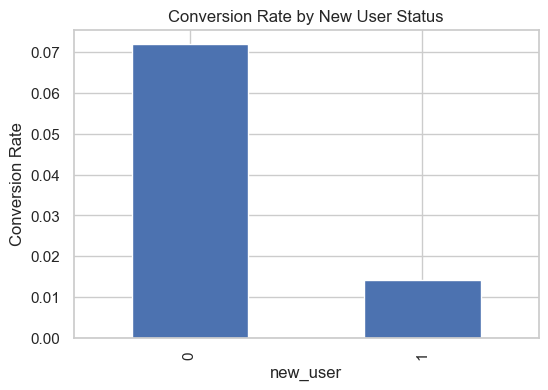

In [54]:
new_user_conversion = train.groupby('new_user')['converted'].mean()

plt.figure(figsize=(6,4))
new_user_conversion.plot(kind='bar')
plt.title('Conversion Rate by New User Status')
plt.ylabel('Conversion Rate')
plt.show()

## 10. Correlation Analysis

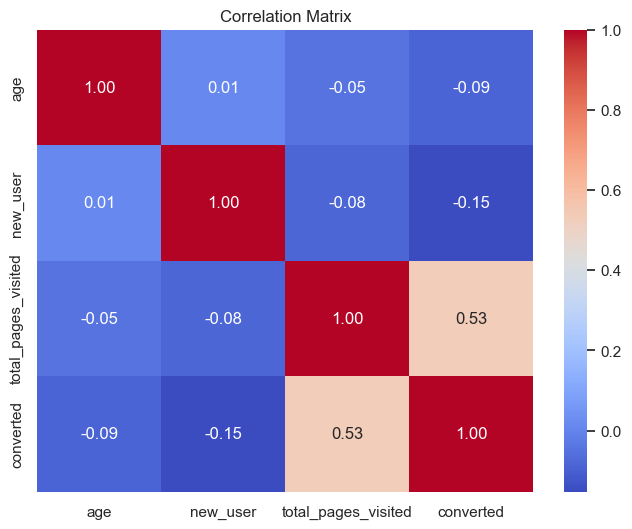

In [55]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 11. Outlier Detection

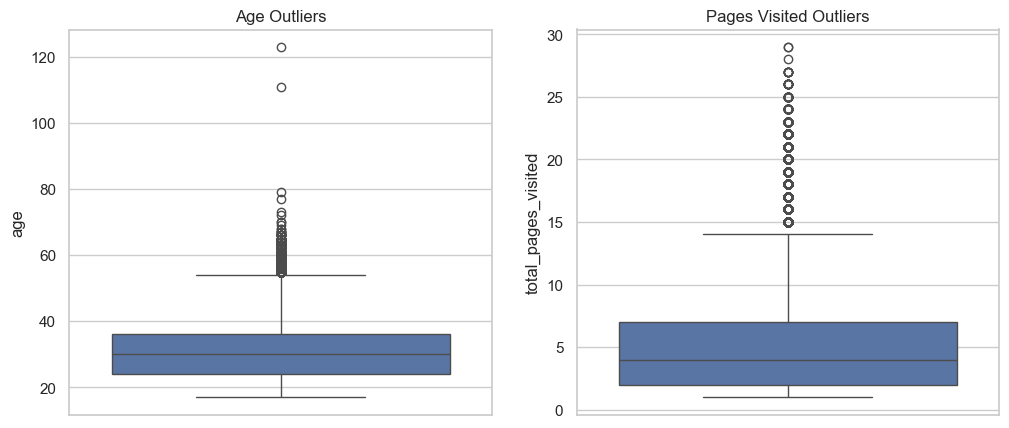

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=train, y='age', ax=axes[0])
axes[0].set_title('Age Outliers')

sns.boxplot(data=train, y='total_pages_visited', ax=axes[1])
axes[1].set_title('Pages Visited Outliers')

plt.show()

## 12. Conversion Insights

In [57]:
train.groupby('converted')['total_pages_visited'].mean()

converted
0     4.550359
1    14.560022
Name: total_pages_visited, dtype: float64

In [58]:
train.groupby('converted')['age'].mean()

converted
0    30.697422
1    26.567647
Name: age, dtype: float64


## 13. Key Findings

### Main Insights

- `total_pages_visited` is the strongest predictor.
- Younger users tend to convert more.
- Country and traffic source influence conversion rates.
- The dataset is imbalanced.

### Recommendations

- Use F1-score for evaluation
- Encode categorical variables
- Scale numerical features if needed
- Try several ML models



## 14. Next Steps

The next notebook will focus on:

1. Preprocessing
2. Baseline model training
3. Hyperparameter tuning
4. Final predictions
